# Лабораторная работа E5 — Контроль качества ЭМГ-записи

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e5.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e5.html)**.

**Что разбираем.** Прежде чем что-то считать по ЭМГ, нужно понять, годится ли
запись вообще. Плохой электрод не выдаёт ошибку — он выдаёт правдоподобные
числа, из которых потом получается неправильная команда.

Четыре типичные поломки канала:

* **клиппинг** — усиление слишком велико, вершины сигнала срезаны потолком АЦП;
* **motion** — рывок кабеля даёт мощный выброс ниже 20 Гц;
* **наводка 50 Гц** — оторванный электрод работает как антенна;
* **нет сигнала** — канал выключен или отвалился, остаётся почти ноль.

Мера пригодности — отношение сигнал/шум:

$$\mathrm{SNR} = 20\log_{10}\frac{\mathrm{RMS}_{\text{активность}}}{\mathrm{RMS}_{\text{покой}}}$$

Годным обычно считают канал с SNR примерно от 10 дБ и выше.

Каждую поломку можно поймать автоматически: у чистой ЭМГ вся энергия лежит в
полосе 20–450 Гц, а артефакт кладёт её не туда — или ломает форму сигнала.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
from scipy.signal import butter, sosfiltfilt, welch
from scipy.integrate import trapezoid

## Ячейка 2 · Вспомогательные функции

Генератор синтетического ЭМГ, три «болячки», расчёт признаков канала,
авто-детектор и рисование. Запусти один раз и дальше просто вызывай.

In [3]:
def synth_emg(t, fs, amp=1.0, band=(20.0, 450.0), seed=5):
    """Шумоподобная ЭМГ-пачка: белый шум, отфильтрованный в полосу ЭМГ и
    промодулированный гауссовой огибающей сокращения."""
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(len(t))
    sos = butter(4, band, btype="band", fs=fs, output="sos")
    x = sosfiltfilt(sos, x)
    total = t[-1] if t[-1] > 0 else 1.0
    envelope = np.exp(-((t - total / 2) / (total / 6)) ** 2)
    x = x / (np.max(np.abs(x)) + 1e-12) * envelope
    return amp * x


def motion_artifact(t, amp=2.6, center=None, freq=1.5):
    """Низкочастотный выброс от рывка кабеля — вся энергия ниже 20 Гц."""
    center = t[-1] / 2 if center is None else center
    return amp * np.exp(-((t - center) / 0.05) ** 2) * np.sin(2 * np.pi * freq * t)


def mains_hum(t, amp=0.6, mains=50.0):
    """Сетевая наводка — то, что ловит оторванный электрод-антенна."""
    return amp * np.sin(2 * np.pi * mains * t)


def rms(x):
    return np.sqrt(np.mean(x ** 2) + 1e-24)


def snr_db(active, rest):
    """Отношение (не разность!) среднеквадратичных уровней, в децибелах."""
    return 20.0 * np.log10(rms(active) / rms(rest))


def channel_features(x, fs, mains=50.0, emg_lo=20.0):
    """Четыре числа, по которым судят о канале.

    clip  — доля отсчётов, залипших ровно на пике (плато от срезки);
    std   — СКО, почти ноль означает отсутствие сигнала;
    mains — доля мощности в полосе 48–52 Гц;
    lf    — доля мощности ниже 20 Гц.
    """
    peak = float(np.max(np.abs(x))) + 1e-12
    clip = float(np.mean(np.abs(x) >= peak - 1e-4)) if peak > 1e-3 else 0.0
    freqs, power = welch(x, fs=fs, nperseg=min(512, len(x)))
    total = trapezoid(power, freqs) + 1e-24
    band_mains = (freqs >= mains - 2.0) & (freqs <= mains + 2.0)
    band_low = freqs <= emg_lo
    return {
        "clip": clip,
        "std": float(np.std(x)),
        "mains": trapezoid(power[band_mains], freqs[band_mains]) / total,
        "lf": trapezoid(power[band_low], freqs[band_low]) / total,
    }


def diagnose(x, fs, thresholds):
    """Вердикт по каналу: список найденных нарушений или «годен»."""
    features = channel_features(x, fs)
    reasons = []
    if features["clip"] > thresholds["clip"]:
        reasons.append("клиппинг (%.0f%% отсчётов на потолке)" % (100 * features["clip"]))
    if features["std"] < thresholds["std"]:
        reasons.append("нет сигнала (СКО=%.3f)" % features["std"])
    if features["mains"] > thresholds["mains"]:
        reasons.append("наводка 50 Гц (%.0f%% мощности)" % (100 * features["mains"]))
    if features["lf"] > thresholds["lf"]:
        reasons.append("motion ниже 20 Гц (%.0f%% мощности)" % (100 * features["lf"]))
    ok = not reasons
    return ok, features, ("ГОДЕН" if ok else "БРАК: " + "; ".join(reasons))


def plot_channels(t, channels, fs, thresholds, seconds=0.2):
    """Сетка «сигнал + вердикт» по всем каналам.

    Окно берётся в середине записи — там, где сокращение, иначе на краях видно
    только тишину и все каналы выглядят одинаково пустыми.
    """
    rows = (len(channels) + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(12, 3.4 * rows))
    middle = len(t) // 2
    half = int(seconds * fs / 2)
    seg = slice(max(0, middle - half), min(len(t), middle + half))
    for axis, (name, x) in zip(np.atleast_1d(axes).ravel(), channels):
        ok, features, _ = diagnose(x, fs, thresholds)
        axis.plot(t[seg], x[seg], color="seagreen" if ok else "crimson", lw=1.0)
        axis.set(xlabel="$t$, с", ylabel="сигнал",
                 title="%s — %s\nклип=%.0f%%, СКО=%.3f, 50 Гц=%.0f%%, НЧ=%.0f%%"
                       % (name, "ГОДЕН" if ok else "БРАК", 100 * features["clip"],
                          features["std"], 100 * features["mains"], 100 * features["lf"]))
    fig.tight_layout()
    plt.show()


def plot_spectra(channels, fs):
    """Спектры всех каналов на одной оси — видно, куда артефакт кладёт энергию."""
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for name, x in channels:
        freqs, power = welch(x, fs=fs, nperseg=512)
        ax.semilogy(freqs, power + 1e-16, lw=1.3, label=name)
    ax.axvspan(0, 20, color="0.85", zorder=0)
    ax.axvline(50, color="0.6", ls=":", lw=1)
    ax.set(xlabel="$f$, Гц", ylabel="спектральная плотность", xlim=(0, 500),
           title="Серая зона — ниже 20 Гц (motion), пунктир — сеть 50 Гц")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Чистый канал и его SNR

Сначала опорная точка: как выглядит хорошая запись и какой у неё SNR.

RMS активности : 0.2237
RMS покоя      : 0.0398
SNR            : 15.0 дБ  (годным считают примерно от 10 дБ)


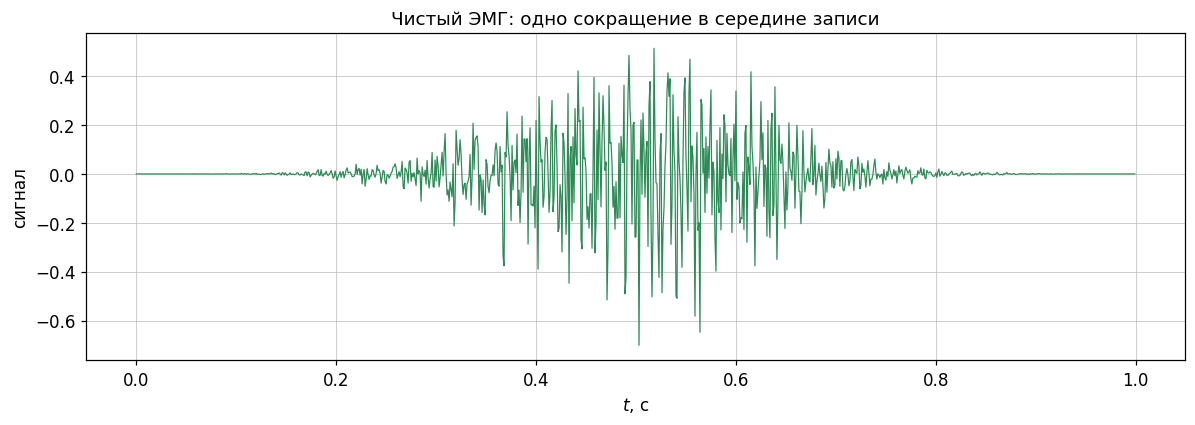

In [4]:
FS = 1000.0        # частота дискретизации, Гц
DUR = 1.0          # длительность записи, с
REST_NOISE = 0.04  # уровень шума покоя на хорошем канале

t = np.arange(0, DUR, 1.0 / FS)
rng = np.random.default_rng(5)

good = synth_emg(t, FS, amp=0.9)
active_part = good[np.abs(t - DUR / 2) < DUR / 8]
rest_part = REST_NOISE * rng.standard_normal(len(t))

print("RMS активности : %.4f" % rms(active_part))
print("RMS покоя      : %.4f" % rms(rest_part))
print("SNR            : %.1f дБ  (годным считают примерно от 10 дБ)"
      % snr_db(active_part, rest_part))

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(t, good, color="seagreen", lw=0.8)
ax.set(xlabel="$t$, с", ylabel="сигнал", title="Чистый ЭМГ: одно сокращение в середине записи")
fig.tight_layout()
plt.show()

## Ячейка 4 · Четыре канала: один годный, три сломанных

Собираем набор так, как он выглядит на реальной манжете: один канал в порядке,
на остальных по одной типичной поломке.

Канал 1 (чистый)           размах 1.14, СКО 0.126
Канал 2 (клиппинг)         размах 2.00, СКО 0.291
Канал 3 (отрыв + 50 Гц)    размах 1.47, СКО 0.495
Канал 4 (motion)           размах 3.18, СКО 0.599


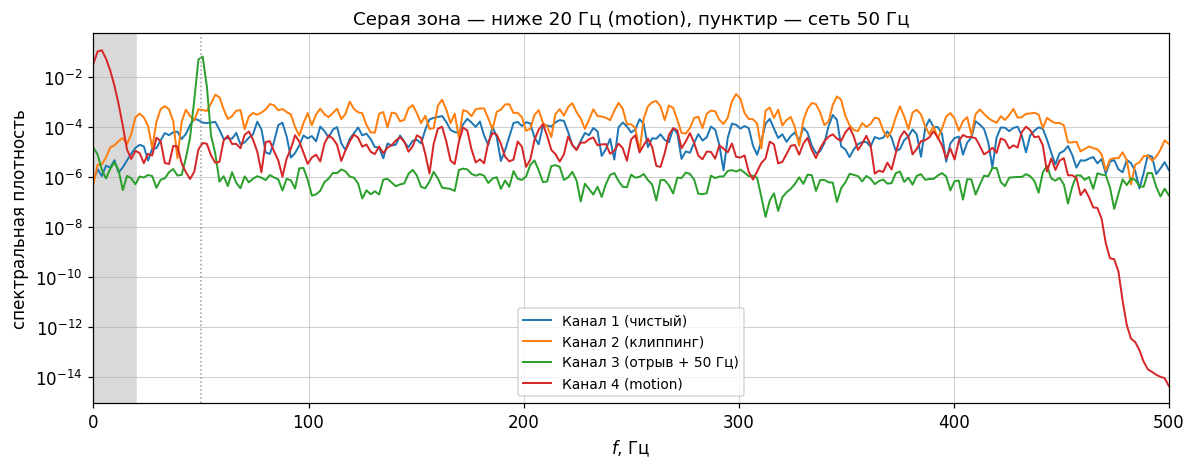

In [5]:
CLIP_GAIN = 2.8    # усиление перед потолком АЦП
CLIP_LEVEL = 1.0   # сам потолок

CHANNELS = [
    ("Канал 1 (чистый)", synth_emg(t, FS, 0.9, seed=5)
                         + REST_NOISE * rng.standard_normal(len(t))),
    ("Канал 2 (клиппинг)", np.clip(CLIP_GAIN * synth_emg(t, FS, 1.0, seed=6),
                                   -CLIP_LEVEL, CLIP_LEVEL)),
    ("Канал 3 (отрыв + 50 Гц)", mains_hum(t, 0.7) + 0.02 * rng.standard_normal(len(t))),
    ("Канал 4 (motion)", synth_emg(t, FS, 0.6, seed=8) + motion_artifact(t)),
]

for name, x in CHANNELS:
    print("%-26s размах %.2f, СКО %.3f" % (name, np.ptp(x), np.std(x)))

plot_spectra(CHANNELS, FS)

## Ячейка 5 · Авто-детектор

Пороги ниже — те же, что в браузерной версии. Меняй их и смотри, как меняется
вердикт: слишком мягкие пропустят брак, слишком жёсткие забракуют годный канал.

Вердикт по каждому каналу:

   Канал 1 (чистый)           ГОДЕН
   Канал 2 (клиппинг)         БРАК: клиппинг (2% отсчётов на потолке)
   Канал 3 (отрыв + 50 Гц)    БРАК: наводка 50 Гц (48% мощности)
   Канал 4 (motion)           БРАК: motion ниже 20 Гц (98% мощности)


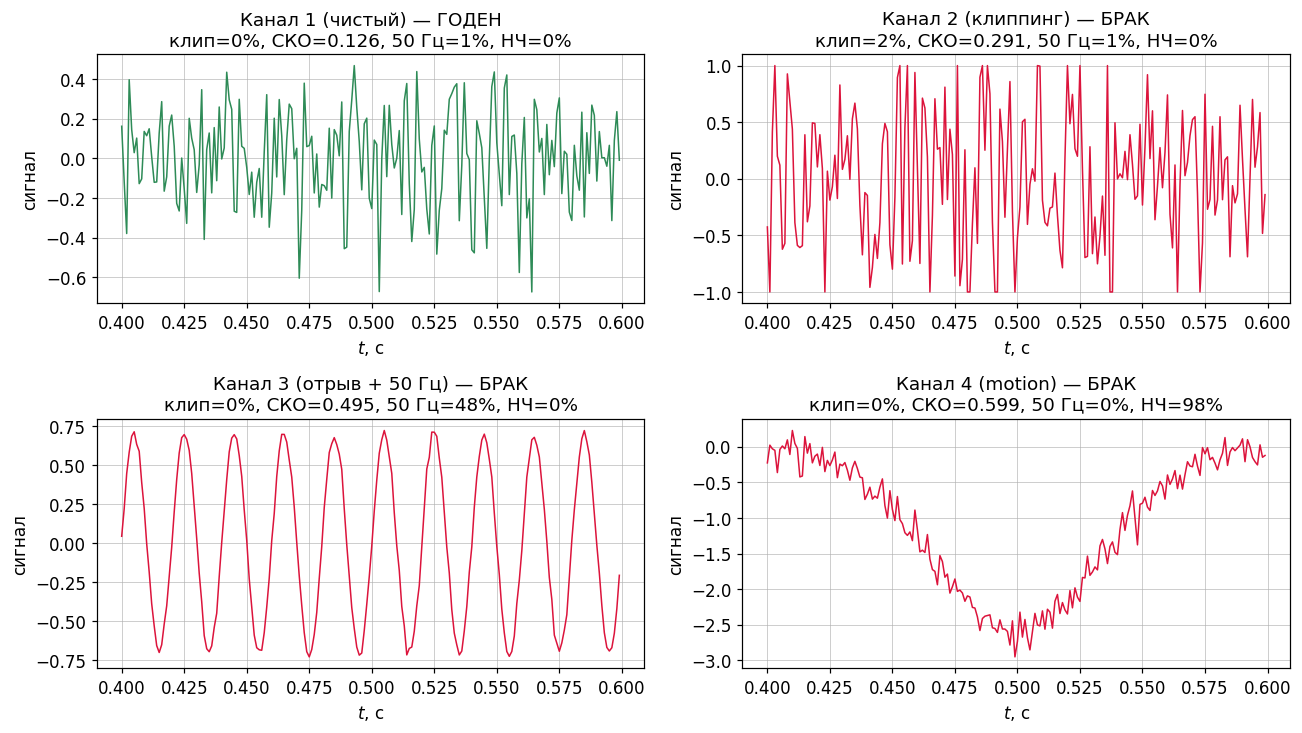

In [6]:
THRESHOLDS = {
    "clip": 0.02,    # доля отсчётов на потолке
    "std": 0.02,     # СКО ниже этого — сигнала нет
    "mains": 0.40,   # доля мощности в 48–52 Гц
    "lf": 0.30,      # доля мощности ниже 20 Гц
}

print("Вердикт по каждому каналу:\n")
for name, x in CHANNELS:
    _, _, verdict = diagnose(x, FS, THRESHOLDS)
    print("   %-26s %s" % (name, verdict))

plot_channels(t, CHANNELS, FS, THRESHOLDS)

Каждая поломка ловится своим признаком, и ни один признак не срабатывает на
чистом канале — в этом и смысл набора из четырёх проверок вместо одной.

## Ячейка 6 · Где проходит граница по усилению

Клиппинг наступает не сразу: до какого-то усиления сигнал только растёт,
а дальше начинает срезаться. Найдём эту точку.

усиление      клип, %          СКО   вердикт
     1.0          0.1        0.114   годен
     1.5          0.1        0.171   годен
     2.0          0.7        0.223   годен
     2.5          1.5        0.267   годен
     3.0          2.7        0.306   брак
     4.0          5.9        0.369   брак


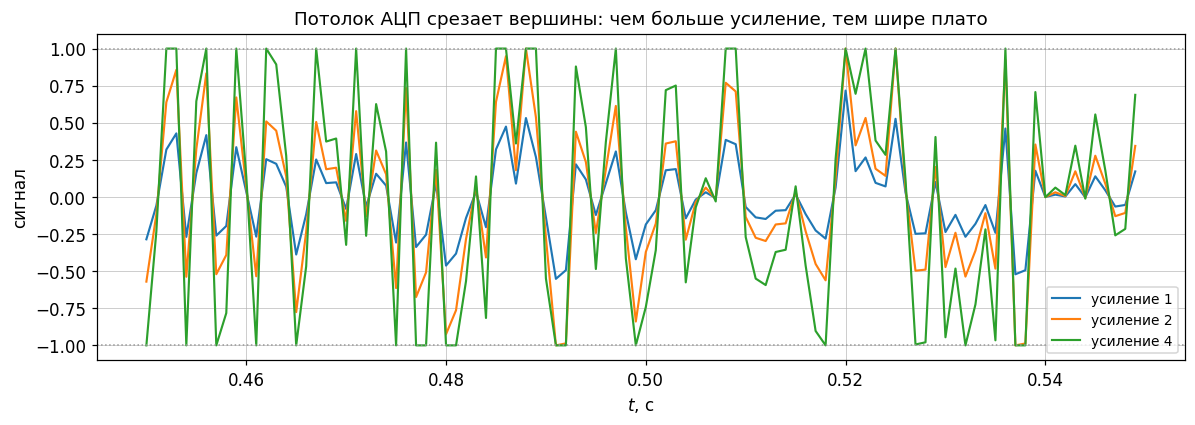

In [7]:
GAINS = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

base = synth_emg(t, FS, 1.0, seed=6)
print("%8s %12s %12s   %s" % ("усиление", "клип, %", "СКО", "вердикт"))
for gain in GAINS:
    x = np.clip(gain * base, -CLIP_LEVEL, CLIP_LEVEL)
    ok, features, _ = diagnose(x, FS, THRESHOLDS)
    print("%8.1f %12.1f %12.3f   %s"
          % (gain, 100 * features["clip"], features["std"], "годен" if ok else "брак"))

fig, ax = plt.subplots(figsize=(11, 4.0))
seg = slice(int(0.45 * FS), int(0.55 * FS))
for gain in (1.0, 2.0, 4.0):
    ax.plot(t[seg], np.clip(gain * base, -CLIP_LEVEL, CLIP_LEVEL)[seg],
            lw=1.4, label="усиление %.0f" % gain)
ax.axhline(CLIP_LEVEL, color="0.6", ls=":", lw=1)
ax.axhline(-CLIP_LEVEL, color="0.6", ls=":", lw=1)
ax.set(xlabel="$t$, с", ylabel="сигнал", title="Потолок АЦП срезает вершины: чем больше усиление, тем шире плато")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Задания

1. Для своих уровней артефактов из таблицы вариантов запиши все четыре
   признака каждого канала и итоговый вердикт.
2. Найди усиление, при котором канал ещё проходит проверку на клиппинг, и
   следующее, при котором уже не проходит. Запиши обе доли залипших отсчётов.
3. Подними шум покоя `REST_NOISE` до уровня, при котором SNR падает ниже
   10 дБ. Запиши это значение и объясни, что оно означает для управления
   протезом.